# 03 — Order Block Research: Baseline Backtest

## Purpose
Establish the BASELINE strategy performance BEFORE any improvements.
This is the control group. Every subsequent notebook compares against this.

## Strategy: Raw Order Block (no filters)
- Displacement: ≥4 same-direction candles, move ≥ 1.5× ATR(14)
- OB: last opposite candle before displacement
- Entry: price retests OB zone with rejection wick
- SL: opposite OB boundary
- TP: entry + (entry-sl) × RR
- NO session filter, NO HTF bias, NO FVG, NO BOS

## What we measure
- Win rate
- Expectancy (avg P&L per trade)
- Profit factor
- Max drawdown
- Trades per month

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.ob_core import list_ob_signals, add_candle_features

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (16, 6)})

SYMBOL    = 'XAUUSDT'
RISK_USDT = 20.0   # $20 risk per trade
RR        = 2.0    # take profit at 2:1

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = m5.sort_index()

print(f'Loaded {len(m5):,} M5 bars — {m5.index[0].date()} to {m5.index[-1].date()}')

Loaded 19,798 M5 bars — 2026-03-09 to 2026-05-17


In [2]:
# ── Generate baseline OB signals ───────────────────────────────────────────
signals = list_ob_signals(m5, risk_cash=RISK_USDT, rr=RR)

print(f'Total OB signals generated: {len(signals)}')
if not signals.empty:
    print(f"Side distribution:\n{signals['side'].value_counts()}")
    print(f"\nOB type:\n{signals['ob_type'].value_counts()}")
    signals.head()

Total OB signals generated: 290
Side distribution:
side
sell    156
buy     134
Name: count, dtype: int64

OB type:
ob_type
bearish    156
bullish    134
Name: count, dtype: int64


In [ ]:
# ── Simple walk-forward backtest ───────────────────────────────────────────
FEE_RATE = 0.00055  # 0.055% per side (entry + exit)

def run_ob_backtest(m5_df, signals_df, start_balance=10000.0):
    """
    Simulate OB trades on M5 data.
    Each signal is filled at the entry price on the next bar.
    TP/SL are evaluated on subsequent bars.
    """
    trades = []
    balance = start_balance
    equity_curve = [(m5_df.index[0], balance)]

    for _, sig in signals_df.iterrows():
        entry_bar = sig['signal_bar_index']
        side      = sig['side']
        entry     = sig['entry']
        sl        = sig['sl']
        tp        = sig['tp']
        qty       = RISK_USDT / abs(entry - sl)

        # Scan forward bars for TP/SL hit
        result = None
        exit_price = None
        exit_time  = None

        for j in range(entry_bar + 1, min(entry_bar + 200, len(m5_df))):
            bar = m5_df.iloc[j]
            hit_sl = (bar['low']  <= sl) if side == 'buy' else (bar['high'] >= sl)
            hit_tp = (bar['high'] >= tp) if side == 'buy' else (bar['low']  <= tp)

            if hit_sl and hit_tp:
                # Both hit same bar — SL takes priority (conservative)
                exit_price = sl
                result = 'loss'
            elif hit_sl:
                exit_price = sl
                result = 'loss'
            elif hit_tp:
                exit_price = tp
                result = 'win'

            if result:
                exit_time = m5_df.index[j]
                break

        if result is None:
            continue  # Signal didn't resolve — skip

        fee = (entry + exit_price) * qty * FEE_RATE
        pnl = ((exit_price - entry) * qty if side == 'buy' else (entry - exit_price) * qty) - fee
        balance += pnl
        equity_curve.append((exit_time, balance))
        trades.append({
            'entry_time': m5_df.index[entry_bar],
            'exit_time' : exit_time,
            'side'      : side,
            'entry'     : entry,
            'sl'        : sl,
            'tp'        : tp,
            'exit'      : exit_price,
            'qty'       : qty,
            'pnl'       : pnl,
            'result'    : result,
            'balance'   : balance,
        })

    trades_df = pd.DataFrame(trades)
    eq = pd.Series({t: v for t, v in equity_curve})
    return trades_df, eq


trades_df, equity = run_ob_backtest(m5, signals)
print(f'Total trades resolved: {len(trades_df)}')

In [4]:
# ── Performance metrics ────────────────────────────────────────────────────
def compute_metrics(trades_df, start_balance=10000.0):
    if trades_df.empty:
        return {}

    wins  = trades_df[trades_df['result'] == 'win']
    losses= trades_df[trades_df['result'] == 'loss']

    win_rate    = len(wins) / len(trades_df)
    avg_win     = wins['pnl'].mean() if len(wins) > 0 else 0
    avg_loss    = losses['pnl'].mean() if len(losses) > 0 else 0
    expectancy  = win_rate * avg_win + (1 - win_rate) * avg_loss

    total_wins  = wins['pnl'].sum() if len(wins) > 0 else 0
    total_losses= abs(losses['pnl'].sum()) if len(losses) > 0 else 1
    profit_factor = total_wins / total_losses if total_losses > 0 else 0

    # Max drawdown
    balances = trades_df['balance'].values
    peak = start_balance
    max_dd = 0
    for b in balances:
        peak = max(peak, b)
        dd = (peak - b) / peak * 100
        max_dd = max(max_dd, dd)

    total_pnl = trades_df['pnl'].sum()
    return {
        'trades'       : len(trades_df),
        'win_rate'     : f'{win_rate*100:.1f}%',
        'expectancy'   : f'{expectancy:.2f} USDT',
        'profit_factor': f'{profit_factor:.2f}',
        'max_drawdown' : f'{max_dd:.1f}%',
        'total_pnl'    : f'{total_pnl:.2f} USDT',
        'avg_win'      : f'{avg_win:.2f} USDT',
        'avg_loss'     : f'{avg_loss:.2f} USDT',
    }


metrics = compute_metrics(trades_df)
print('\n=== BASELINE STRATEGY METRICS ===')
for k, v in metrics.items():
    print(f'  {k:20s}: {v}')


=== BASELINE STRATEGY METRICS ===
  trades              : 285
  win_rate            : 51.2%
  expectancy          : 10.74 USDT
  profit_factor       : 2.10
  max_drawdown        : 1.0%
  total_pnl           : 3060.00 USDT
  avg_win             : 40.00 USDT
  avg_loss            : -20.00 USDT


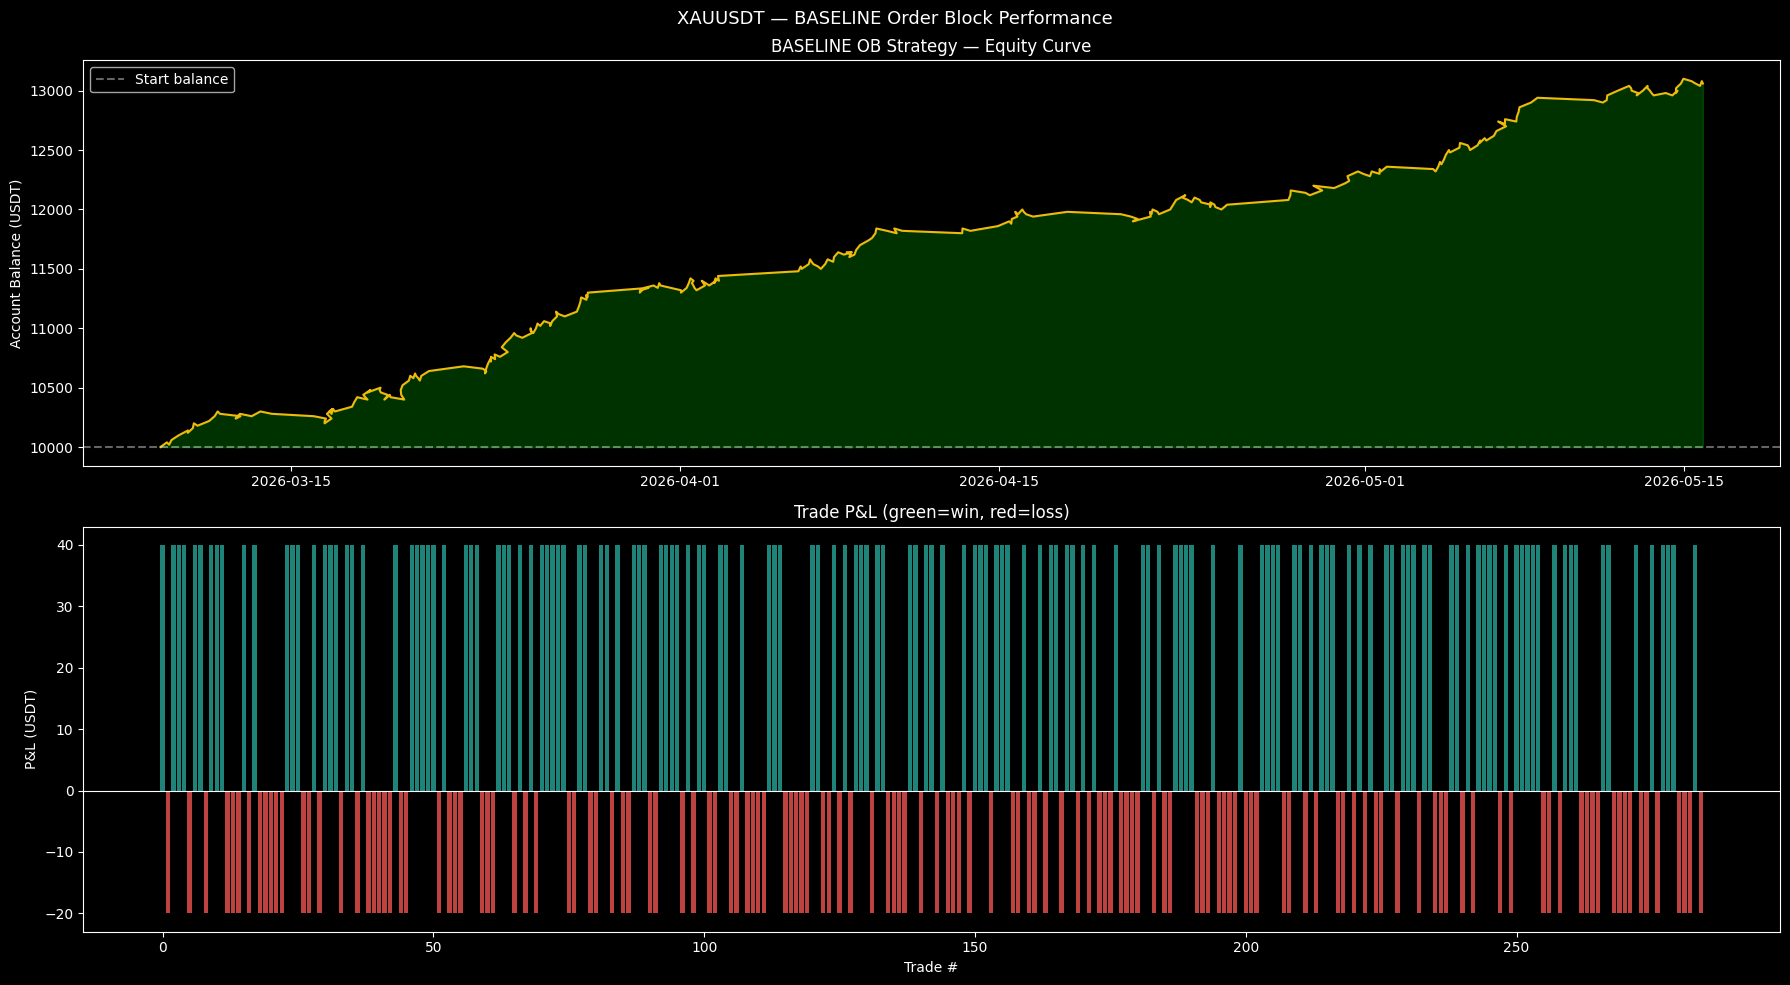


Baseline metrics saved for comparison in notebook 12.
Saved to notebooks_ob/results/baseline_metrics.json


In [5]:
# ── Equity curve ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Equity curve
axes[0].plot(equity.index, equity.values, color='#F0B90B', linewidth=1.5)
axes[0].axhline(10000, color='white', linestyle='--', alpha=0.4, label='Start balance')
axes[0].fill_between(equity.index, 10000, equity.values,
                     where=equity.values >= 10000, color='lime', alpha=0.2)
axes[0].fill_between(equity.index, 10000, equity.values,
                     where=equity.values < 10000, color='red', alpha=0.2)
axes[0].set_title('BASELINE OB Strategy — Equity Curve')
axes[0].set_ylabel('Account Balance (USDT)')
axes[0].legend()

# Trade P&L distribution
if not trades_df.empty:
    colors = ['#26a69a' if r == 'win' else '#ef5350' for r in trades_df['result']]
    axes[1].bar(range(len(trades_df)), trades_df['pnl'], color=colors, alpha=0.8)
    axes[1].axhline(0, color='white', linewidth=0.8)
    axes[1].set_title('Trade P&L (green=win, red=loss)')
    axes[1].set_xlabel('Trade #')
    axes[1].set_ylabel('P&L (USDT)')

plt.suptitle(f'{SYMBOL} — BASELINE Order Block Performance', fontsize=13)
plt.tight_layout()
plt.show()

print('\nBaseline metrics saved for comparison in notebook 12.')

# Save baseline metrics for comparison
import json, os
os.makedirs('../notebooks_ob/results', exist_ok=True)
with open('../notebooks_ob/results/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved to notebooks_ob/results/baseline_metrics.json')